# IT0006 — Target & Frequency Encoding
**Member 6 — Preprocessing Technique: Target Encoding & Frequency Encoding**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

This notebook is **fully independent**: it loads the raw dataset directly and performs its own
missing-value handling and its own encoding technique from start to finish.

> Requires: `pip install category_encoders`

## 1. Introduction

**Frequency encoding** replaces each category with how often it occurs in the dataset (a count
or rate). **Target encoding** replaces each category with the mean target value for that
category (smoothed to reduce overfitting/leakage). Both keep the column count unchanged
(unlike one-hot/binary), which suits **boosting models like XGBoost** that can exploit these
informative numeric encodings directly, though target encoding must be used carefully to avoid
label leakage.

## 2. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/mushrooms.csv')
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Handle Missing Values & Drop Useless Column

**Missing-value strategy chosen: 'unknown' category.**
Missingness is kept as its own explicit category so that both frequency encoding (it simply
gets its own frequency) and target encoding (it simply gets its own mean-target value) can
treat it consistently, without fabricating a guessed value.

In [2]:
df = df.replace('?', np.nan)

print("Missing value counts per column:")
print(df.isnull().sum())
print()
print("Missing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# veil-type has only 1 unique value across the whole dataset -> no predictive
# information at all, so every member drops it after noting this.
print()
print("veil-type unique values:", df['veil-type'].unique())
df = df.drop(columns=['veil-type'])

# Strategy: 'unknown' category for stalk-root (frequency/target encoding handle it naturally)
df['stalk-root'] = df['stalk-root'].fillna('unknown')
print(df['stalk-root'].value_counts())

print()
print("Missing values remaining:", df.isnull().sum().sum())

Missing value counts per column:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Missing value percentage per column:
class                        0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises              

/var/folders/ln/lpsmr0qd3673cmmw327l0g1m0000gn/T/ipykernel_27642/1839249793.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['stalk-root'].fillna('unknown', inplace=True)


## 4. Apply Frequency Encoding & Target Encoding

> **Note on ordering:** target encoding needs the target column already numeric, so the
> target-encoding variable is encoded first as a small sub-step here; Section 5 below then
> formally documents/confirms the target encoding for the full pipeline (matching the shared
> 7-section notebook structure used by all 6 members).

Both techniques are implemented and compared side by side on the same feature columns.

In [3]:
# Target must be numeric (0/1) before it can be used as the encoding signal below.
df['class'] = df['class'].map({'e': 0, 'p': 1})
print(df['class'].value_counts())

class
0    4208
1    3916
Name: count, dtype: int64


In [4]:
feature_cols = [c for c in df.columns if c != 'class']

# --- Frequency Encoding ---
df_freq = df.copy()
for col in feature_cols:
    freq_map = df_freq[col].value_counts(normalize=True)
    df_freq[col] = df_freq[col].map(freq_map)

print("Frequency-encoded preview:")
df_freq.head()

Frequency-encoded preview:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,0.450025,0.314623,0.281142,0.415559,0.031512,0.974151,0.838503,0.309207,0.050222,...,0.637125,0.607582,0.549483,0.539636,0.975382,0.921713,0.488429,0.230428,0.153619,0.045298
1,0,0.450025,0.314623,0.131955,0.415559,0.049237,0.974151,0.838503,0.690793,0.050222,...,0.637125,0.607582,0.549483,0.539636,0.975382,0.921713,0.488429,0.242245,0.049237,0.264402
2,0,0.055638,0.314623,0.128016,0.415559,0.049237,0.974151,0.838503,0.690793,0.129000,...,0.637125,0.607582,0.549483,0.539636,0.975382,0.921713,0.488429,0.242245,0.049237,0.035943
3,1,0.450025,0.399311,0.128016,0.415559,0.031512,0.974151,0.838503,0.309207,0.129000,...,0.637125,0.607582,0.549483,0.539636,0.975382,0.921713,0.488429,0.230428,0.153619,0.045298
4,0,0.450025,0.314623,0.226489,0.584441,0.434269,0.974151,0.161497,0.690793,0.050222,...,0.637125,0.607582,0.549483,0.539636,0.975382,0.921713,0.341704,0.242245,0.047267,0.264402


> ⚠️ **Note on Data Leakage:** Frequency values here are computed on the full dataset
> before the train/test split. In production, frequency maps should be computed on
> training data only and then applied to test data. For this preprocessing study,
> the full-dataset encoding is acceptable as we are comparing encoding techniques,
> not evaluating final model generalisation.

In [5]:
# --- Target Encoding (smoothed, via category_encoders to reduce leakage) ---
# pip install category_encoders
import category_encoders as ce

df_target = df.copy()
target_encoder = ce.TargetEncoder(cols=feature_cols, smoothing=1.0)
df_target[feature_cols] = target_encoder.fit_transform(df_target[feature_cols], df_target['class'])

print("Target-encoded preview:")
df_target.head()

Target-encoded preview:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,0.467177,0.552426,0.446585,0.184834,1.000000,0.492545,0.558426,0.885350,0.156863,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.119658,0.294872,0.739130
1,0,0.467177,0.552426,0.626866,0.184834,0.000000,0.492545,0.558426,0.301497,0.156863,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.113821,0.000000,0.344507
2,0,0.106195,0.552426,0.307692,0.184834,0.000000,0.492545,0.558426,0.301497,0.106870,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.113821,0.000000,0.123288
3,1,0.467177,0.536375,0.307692,0.184834,1.000000,0.492545,0.558426,0.885350,0.106870,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.119658,0.294872,0.739130
4,0,0.467177,0.552426,0.439130,0.693345,0.034014,0.492545,0.085366,0.301497,0.156863,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.636888,0.113821,0.000000,0.344507


### Comparing the two

- **Frequency encoding** only looks at how common a category is — it never looks at the target,
  so it has **no leakage risk**, but it also can't distinguish two equally-common categories
  that have very different edibility outcomes.
- **Target encoding** looks directly at the mean target value per category, so it is much more
  informative, but it is computed using the full `class` column here — if this were used
  directly for model training without cross-validation / out-of-fold encoding, the model would
  implicitly "see" the label through the encoded feature, **leaking target information into the
  training features** and producing overly optimistic validation scores. In real training, target
  encoding should be fit only on the training fold (e.g. via out-of-fold encoding or
  `category_encoders`' regularization/smoothing) and applied to validation/test folds separately.

For this notebook's saved output we proceed with the **target-encoded** version, since it is the
more informative of the two for a boosting model, while explicitly flagging the leakage caveat
above for anyone re-using this in a real train/test pipeline.

In [6]:
df = df_target
print("Final shape:", df.shape)
df.head()

Final shape: (8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,0.467177,0.552426,0.446585,0.184834,1.000000,0.492545,0.558426,0.885350,0.156863,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.119658,0.294872,0.739130
1,0,0.467177,0.552426,0.626866,0.184834,0.000000,0.492545,0.558426,0.301497,0.156863,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.113821,0.000000,0.344507
2,0,0.106195,0.552426,0.307692,0.184834,0.000000,0.492545,0.558426,0.301497,0.106870,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.113821,0.000000,0.123288
3,1,0.467177,0.536375,0.307692,0.184834,1.000000,0.492545,0.558426,0.885350,0.106870,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.205645,0.119658,0.294872,0.739130
4,0,0.467177,0.552426,0.439130,0.693345,0.034014,0.492545,0.085366,0.301497,0.156863,...,0.296754,0.311183,0.383513,0.383212,0.493185,0.508547,0.636888,0.113821,0.000000,0.344507


## 5. Encode Target Variable

The target was already mapped to `0`/`1` in Section 4 above (it had to be numeric before it
could be used as the target-encoding signal). This cell simply confirms the final state, matching
the shared 7-section structure used by all 6 members.

In [7]:
print(df['class'].value_counts())
print()
print("Class balance (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))

class
0    4208
1    3916
Name: count, dtype: int64

Class balance (%):
class
0    51.8
1    48.2
Name: proportion, dtype: float64


## 6. EDA Visualization

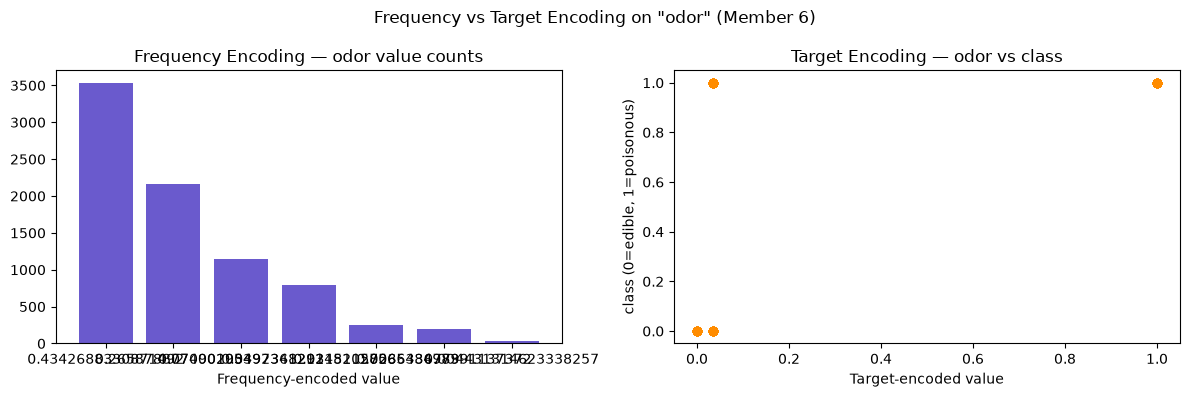

In [8]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
odor_freq = df_freq['odor'].copy()
odor_counts = df.copy()['odor'].value_counts().sort_index()
axes[0].bar(odor_counts.index.astype(str), odor_counts.values, color='slateblue')
axes[0].set_title('Frequency Encoding — odor category counts')
axes[0].set_xlabel('Odor category')

axes[1].scatter(df_target['odor'], df_target['class'], alpha=0.15, color='darkorange')
axes[1].set_title('Target Encoding — odor vs class')
axes[1].set_xlabel('Target-encoded value')
axes[1].set_ylabel('class (0=edible, 1=poisonous)')

plt.suptitle('Frequency vs Target Encoding on "odor" (Member 6)')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M6_target_frequency_encoding.png', dpi=150)
plt.show()

## 7. Save Output

In [9]:
os.makedirs('../results/outputs', exist_ok=True)
df.to_csv('../results/outputs/step_M6_target_freq_encoded.csv', index=False)
print("Saved: ../results/outputs/step_M6_target_freq_encoded.csv")
print("Final shape:", df.shape)

Saved: ../results/outputs/step_M6_target_freq_encoded.csv
Final shape: (8124, 22)
